## PCA

In [111]:
import pandas as pd
from sklearn.decomposition import PCA

# Load data and extract features
df = pd.read_csv("../data/Qualifying_scaled_for_clustering.csv")
identifiers = ['track', 'global_corner_id', 'driver_number']
features = df.drop(columns=identifiers)

# Apply PCA retaining 95% of variance
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(features)

Performing PCA Allows us to "group" similar columns, thus making the clustering process easier

## Finding the ideal number of clusters

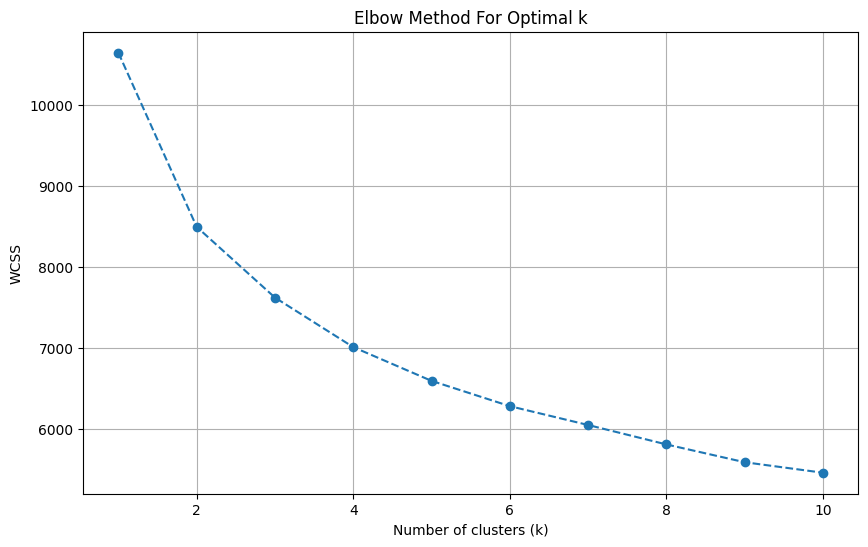

In [112]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

We can see here that after k=3 the decrese is more moderete, therfore we can take k=3 for the most efficient clustering

## K-Means

In [113]:
from sklearn.cluster import KMeans

# Run K-Means and save labels to the original dataframe
kmeans = KMeans(n_clusters=2, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(pca_data)

## DBSCAN

In [114]:
from sklearn.cluster import DBSCAN

# Run DBSCAN and save labels to the original dataframe
dbscan = DBSCAN(eps=0.7, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(pca_data)

## Visualization - HEATMAP

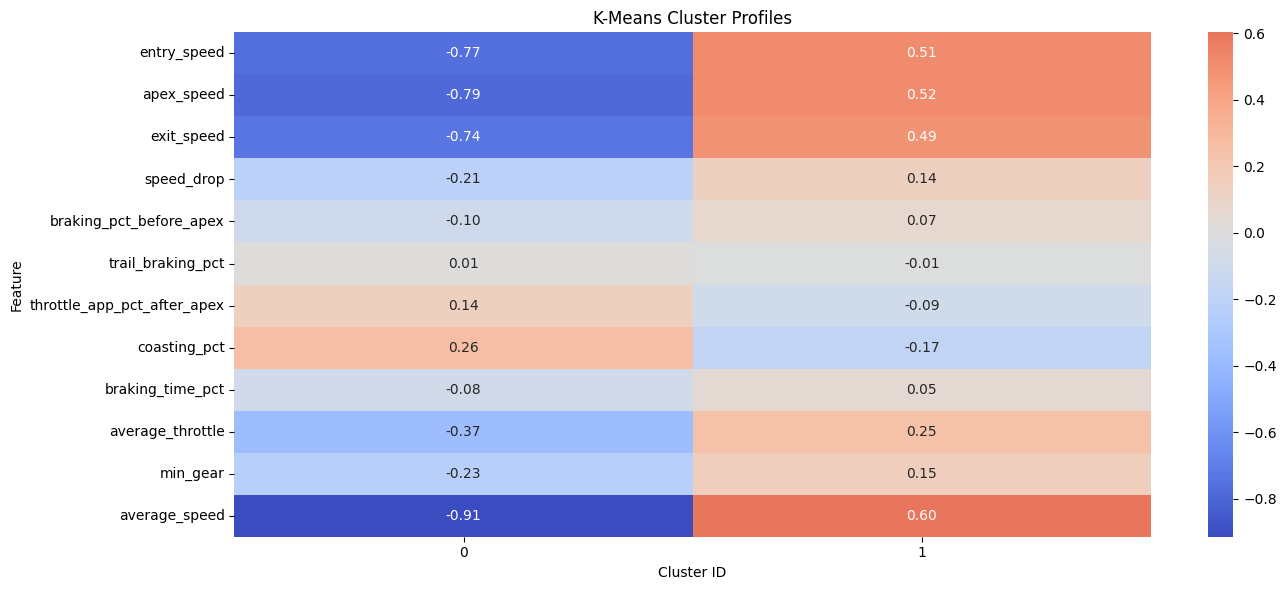

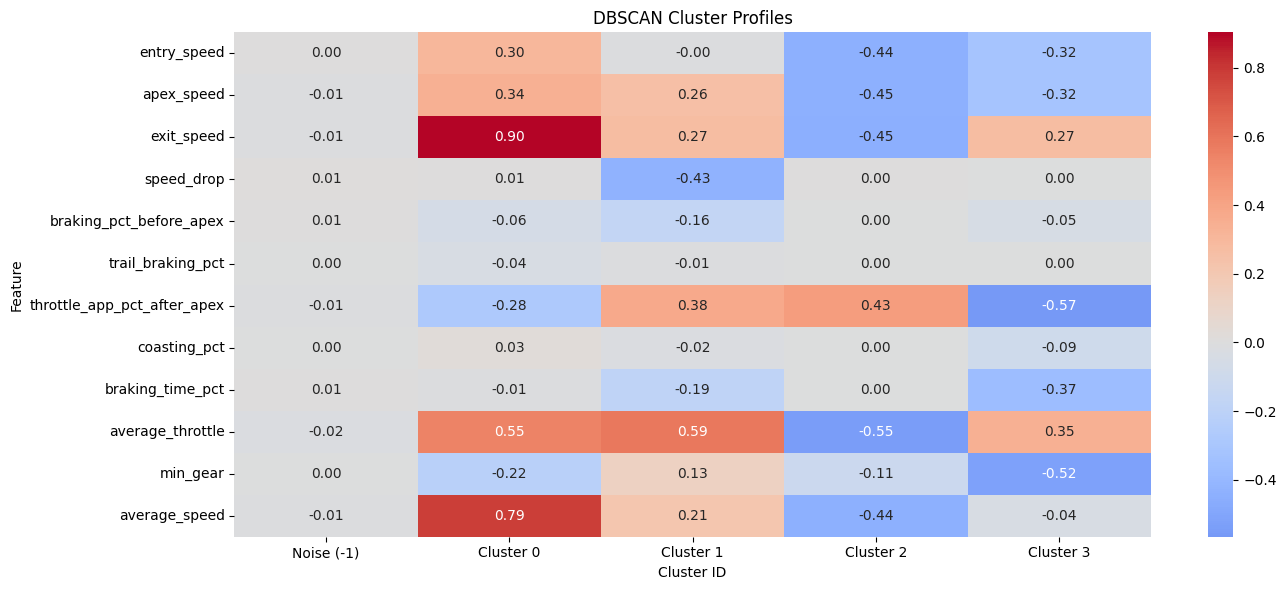

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate feature means for K-Means
kmeans_means = df.groupby('kmeans_cluster')[features.columns].mean()

# Plot K-Means Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(kmeans_means.T, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('K-Means Cluster Profiles')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Calculate feature means for DBSCAN
dbscan_means = df.groupby('dbscan_cluster')[features.columns].mean()
dbscan_means.index = [f'Noise (-1)' if c == -1 else f'Cluster {c}' for c in dbscan_means.index]

# Plot DBSCAN Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(dbscan_means.T, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('DBSCAN Cluster Profiles')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Visualization - BARPLOT

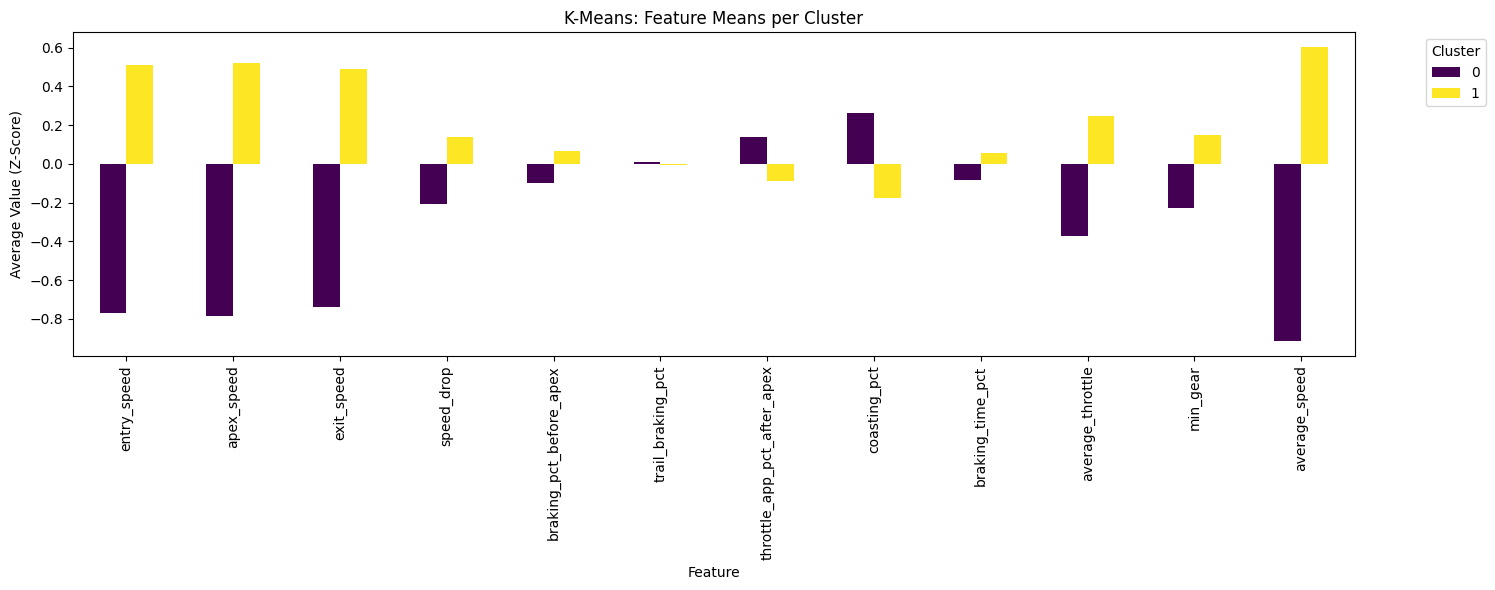

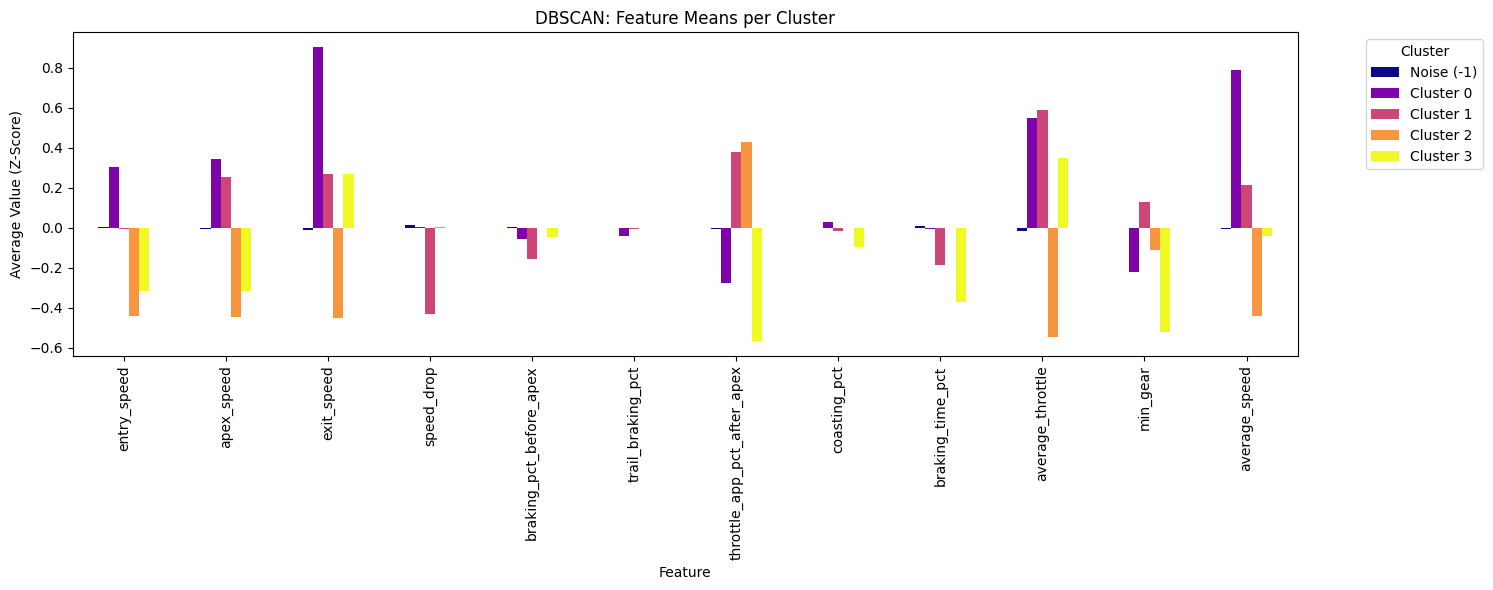

In [116]:
# Plot K-Means Bar Chart
kmeans_means.T.plot(kind='bar', figsize=(15, 6), colormap='viridis')
plt.title('K-Means: Feature Means per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value (Z-Score)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot DBSCAN Bar Chart
dbscan_means.T.plot(kind='bar', figsize=(15, 6), colormap='plasma')
plt.title('DBSCAN: Feature Means per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value (Z-Score)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

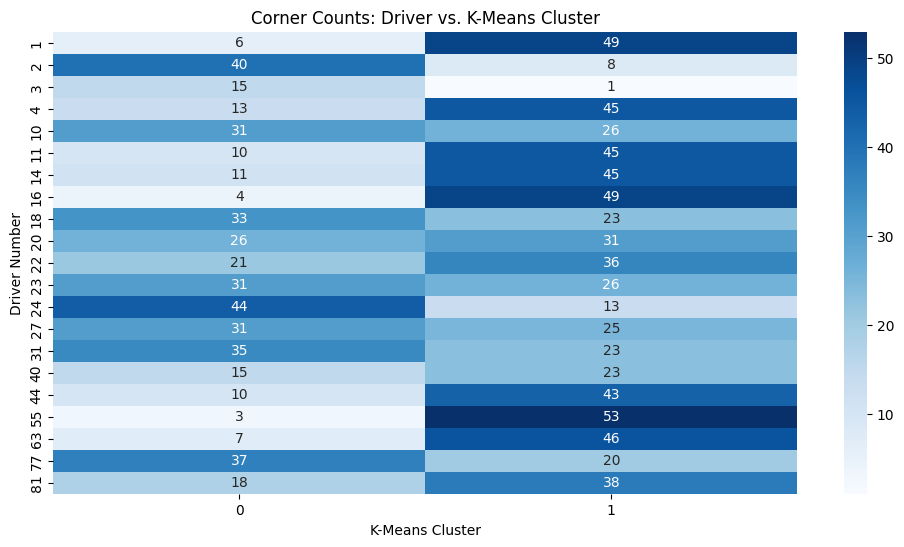

Total specific corners driven differently by the same driver: 0


In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Macro: Driver vs. K-Means Cluster distribution
driver_cluster_dist = pd.crosstab(df['driver_number'], df['kmeans_cluster'])

plt.figure(figsize=(12, 6))
sns.heatmap(driver_cluster_dist, annot=True, fmt="d", cmap="Blues")
plt.title('Corner Counts: Driver vs. K-Means Cluster')
plt.xlabel('K-Means Cluster')
plt.ylabel('Driver Number')
plt.show()

# 2. Micro: Did a driver perform the exact same corner in different ways across laps?
corner_consistency = df.groupby(['track', 'global_corner_id', 'driver_number'])['kmeans_cluster'].nunique()
inconsistent_corners = corner_consistency[corner_consistency > 1]

print(f"Total specific corners driven differently by the same driver: {len(inconsistent_corners)}")

if len(inconsistent_corners) > 0:
    print("\nExamples of inconsistent corners (Track, Corner ID, Driver Number):")
    print(inconsistent_corners.head())

## final clustering

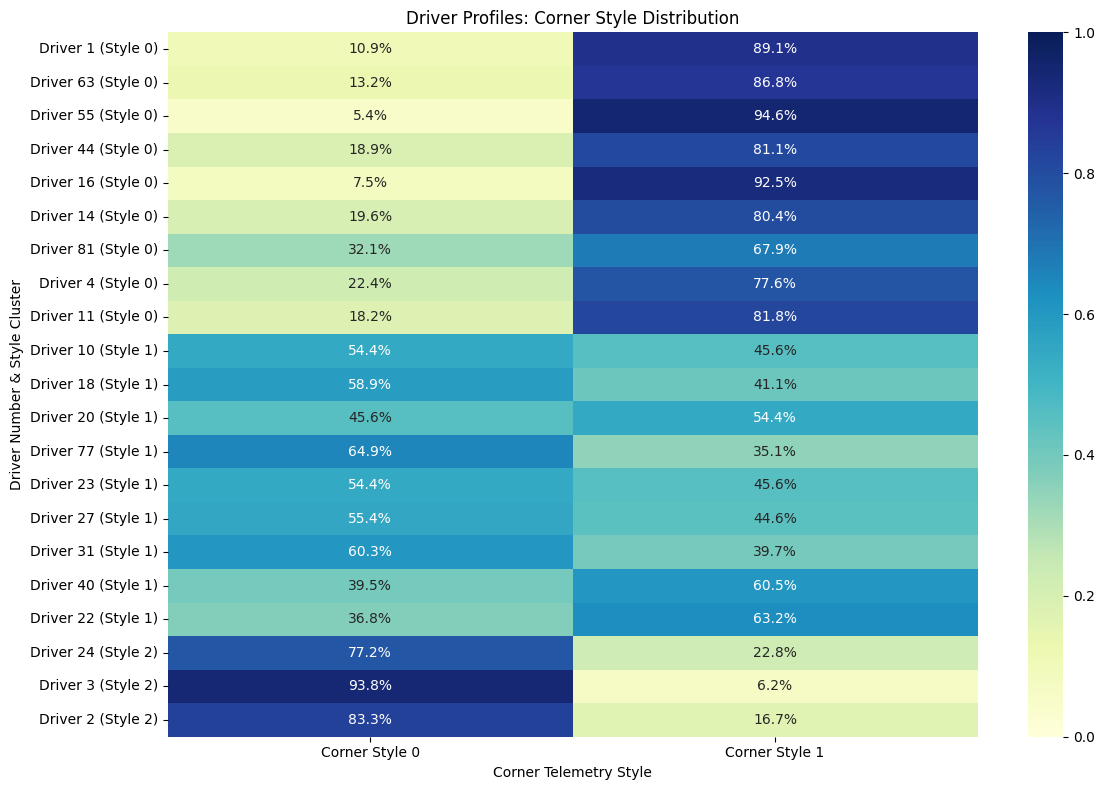

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

driver_profiles = pd.crosstab(df['driver_number'], df['kmeans_cluster'], normalize='index')
driver_profiles.columns = [f'Corner Style {c}' for c in driver_profiles.columns]

kmeans_drivers = KMeans(n_clusters=3, random_state=42)
driver_profiles['Driver_Style_Cluster'] = kmeans_drivers.fit_predict(driver_profiles)

driver_profiles_sorted = driver_profiles.sort_values('Driver_Style_Cluster')
cluster_labels = driver_profiles_sorted.pop('Driver_Style_Cluster')

plt.figure(figsize=(12, 8))
sns.heatmap(driver_profiles_sorted, annot=True, fmt=".1%", cmap="YlGnBu", vmin=0, vmax=1)

y_labels = [f"Driver {idx} (Style {c})" for idx, c in zip(driver_profiles_sorted.index, cluster_labels)]
plt.yticks(ticks=[i + 0.5 for i in range(len(y_labels))], labels=y_labels, rotation=0)

plt.title('Driver Profiles: Corner Style Distribution')
plt.ylabel('Driver Number & Style Cluster')
plt.xlabel('Corner Telemetry Style')
plt.tight_layout()
plt.show()

driver_profiles_sorted['Driver_Style_Cluster'] = cluster_labels

## Second PCA

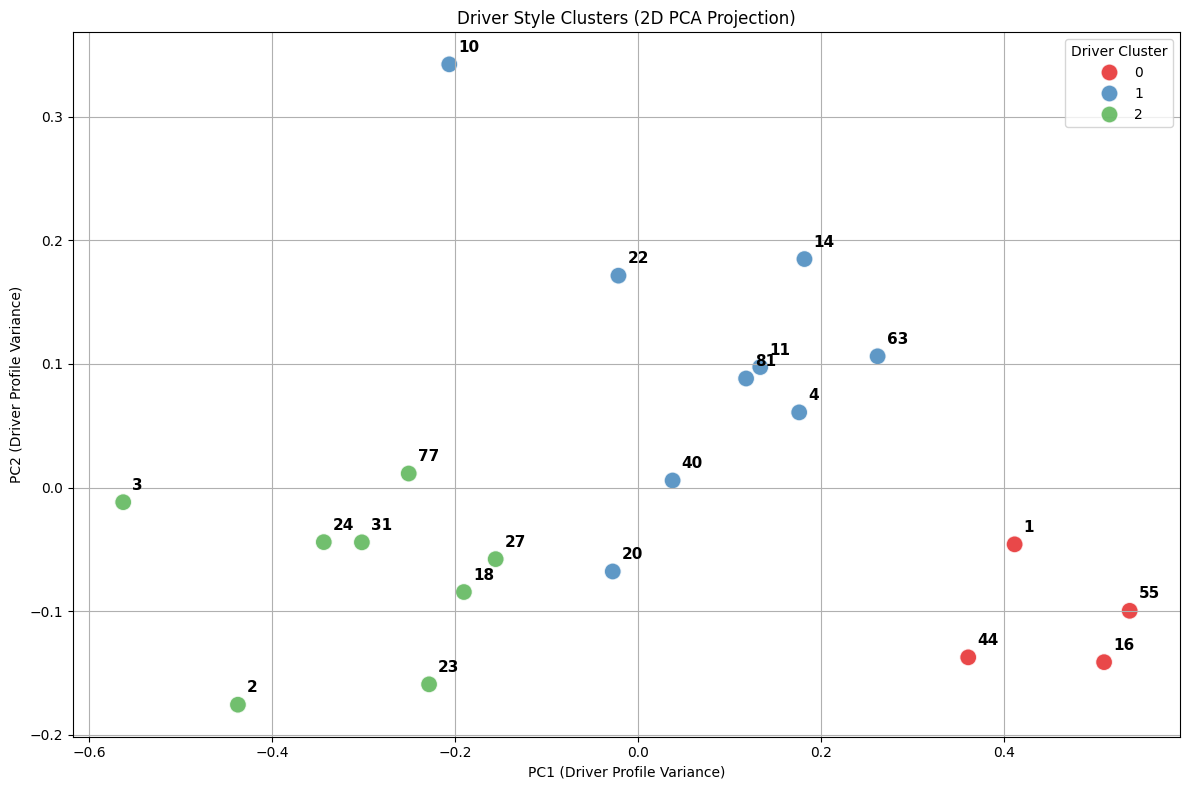

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Load data and process corners
df = pd.read_csv("../data/Qualifying_scaled_for_clustering.csv")
identifiers = ['track', 'global_corner_id', 'driver_number']
features = df.drop(columns=identifiers)

pca_corners = PCA(n_components=0.95)
pca_corners_data = pca_corners.fit_transform(features)

kmeans_corners = KMeans(n_clusters=3, random_state=42)
df['corner_style'] = kmeans_corners.fit_predict(pca_corners_data)

# 2. Create driver profiles and cluster the drivers
driver_profiles = pd.crosstab(df['driver_number'], df['corner_style'], normalize='index')

kmeans_drivers = KMeans(n_clusters=3, random_state=42)
driver_clusters = kmeans_drivers.fit_predict(driver_profiles)
driver_profiles['driver_cluster'] = driver_clusters

# 3. Reduce driver profiles to 2D for the scatter plot
pca_drivers = PCA(n_components=2)
driver_features = driver_profiles.drop(columns=['driver_cluster'])
pca_drivers_2d = pca_drivers.fit_transform(driver_features)

# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=pca_drivers_2d[:, 0], 
    y=pca_drivers_2d[:, 1], 
    hue=driver_clusters, 
    palette='Set1', 
    s=150, 
    alpha=0.8
)

# Annotate each point with the driver number
for i, driver_num in enumerate(driver_profiles.index):
    plt.text(
        pca_drivers_2d[i, 0] + 0.01, 
        pca_drivers_2d[i, 1] + 0.01, 
        str(driver_num), 
        fontsize=11, 
        weight='bold'
    )

plt.title('Driver Style Clusters (2D PCA Projection)')
plt.xlabel('PC1 (Driver Profile Variance)')
plt.ylabel('PC2 (Driver Profile Variance)')
plt.legend(title='Driver Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()